<!-- CODEx Chinese cell explanation: start -->
### Cell 01 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 01 — Computational step 01

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [1]:

import warnings
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
})

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = PROJECT_ROOT / "outputs_step2"
OUT_DIR = PROJECT_ROOT / "outputs_step3"
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"

for p in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATA_DIR / "step1_simulation_dataset.csv"
SRC_PATH = STEP2_DIR / "src_indices_bootstrap.csv"

TARGET = "eui_kwh_m2"
RANDOM_SEED = 42
FAST_MODE = os.environ.get("EUI_FAST_MODE", "0") == "1"
INNER_CV = 3 if FAST_MODE else 10
SEARCH_N_ITER = 3 if FAST_MODE else 20

<!-- CODEx Chinese cell explanation: start -->
### Cell 02 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 02 — Computational step 02

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [2]:
assert DATASET_PATH.exists(), "Please complete Step 1 first"
assert SRC_PATH.exists(), "Please complete Step 2 first"

df = pd.read_csv(DATASET_PATH)
src_df = pd.read_csv(SRC_PATH)

# Use the same feature engineering as in Step 2.
df["orientation_sin"] = np.sin(np.deg2rad(df["orientation_deg"]))
df["orientation_cos"] = np.cos(np.deg2rad(df["orientation_deg"]))
df = pd.get_dummies(df, columns=["window_type_id"], prefix="window_type", drop_first=True)

analysis_features = [
    'insul_thick', 'wwr', 'wall_thick',
    'u_win_n', 'u_win_s', 'u_win_e', 'u_win_w',
    'u_wall', 'u_roof', 'u_ground',
    'shgc_n', 'shgc_s', 'shgc_e', 'shgc_w',
    'roof_insul_thick',
    'floor_num', 'footprint_area_m2', 'aspect_ratio', 'floor_height',
    'orientation_sin', 'orientation_cos',
    'public_area', 'room_area', 'room_count',
    'equip_power', 'dhw_per_person', 'occupancy_density', 'light_power',
    'cool_set', 'heat_set', 'dhw_temp',
    'cop_cooling', 'cop_heating', 'boiler_eff', 'fan_eff',
    'fresh_air_ach', 'operation_hours',
    'window_type_2', 'window_type_3'
]

src_df = src_df[src_df["feature"].isin(analysis_features)].copy()
top18 = src_df.sort_values("abs_SRC", ascending=False).head(18)["feature"].tolist()
fixed_features = [f for f in analysis_features if f not in top18]

X = df[top18].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True
)

top18_range_df = pd.DataFrame({
    "feature": top18,
    "min": [df[f].min() for f in top18],
    "max": [df[f].max() for f in top18],
    "mean": [df[f].mean() for f in top18],
    "median": [df[f].median() for f in top18],
})

fixed_constants_df = pd.DataFrame({
    "feature": fixed_features,
    "fixed_value": [df[f].median() for f in fixed_features]
})

pd.Series(top18, name="top18_variable_features").to_csv(
    OUT_DIR / "top18_variable_features.csv", index=False, encoding="utf-8-sig"
)
top18_range_df.to_csv(
    OUT_DIR / "top18_variable_ranges.csv", index=False, encoding="utf-8-sig"
)
fixed_constants_df.to_csv(
    OUT_DIR / "fixed_background_constants.csv", index=False, encoding="utf-8-sig"
)
print("Top18 features:", top18)
print("X shape:", X.shape)
print("Train/Test:", X_train.shape, X_test.shape)

Top18 features: ['dhw_per_person', 'floor_num', 'room_count', 'footprint_area_m2', 'dhw_temp', 'boiler_eff', 'operation_hours', 'wwr', 'orientation_sin', 'orientation_cos', 'u_roof', 'fresh_air_ach', 'heat_set', 'aspect_ratio', 'shgc_w', 'occupancy_density', 'light_power', 'cop_heating']
X shape: (121, 18)
Train/Test: (96, 18) (25, 18)


<!-- CODEx Chinese cell explanation: start -->
### Cell 03 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 03 — Computational step 03

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [3]:
print(len(df))

121


<!-- CODEx Chinese cell explanation: start -->
### Cell 04 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 04 — Computational step 04

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

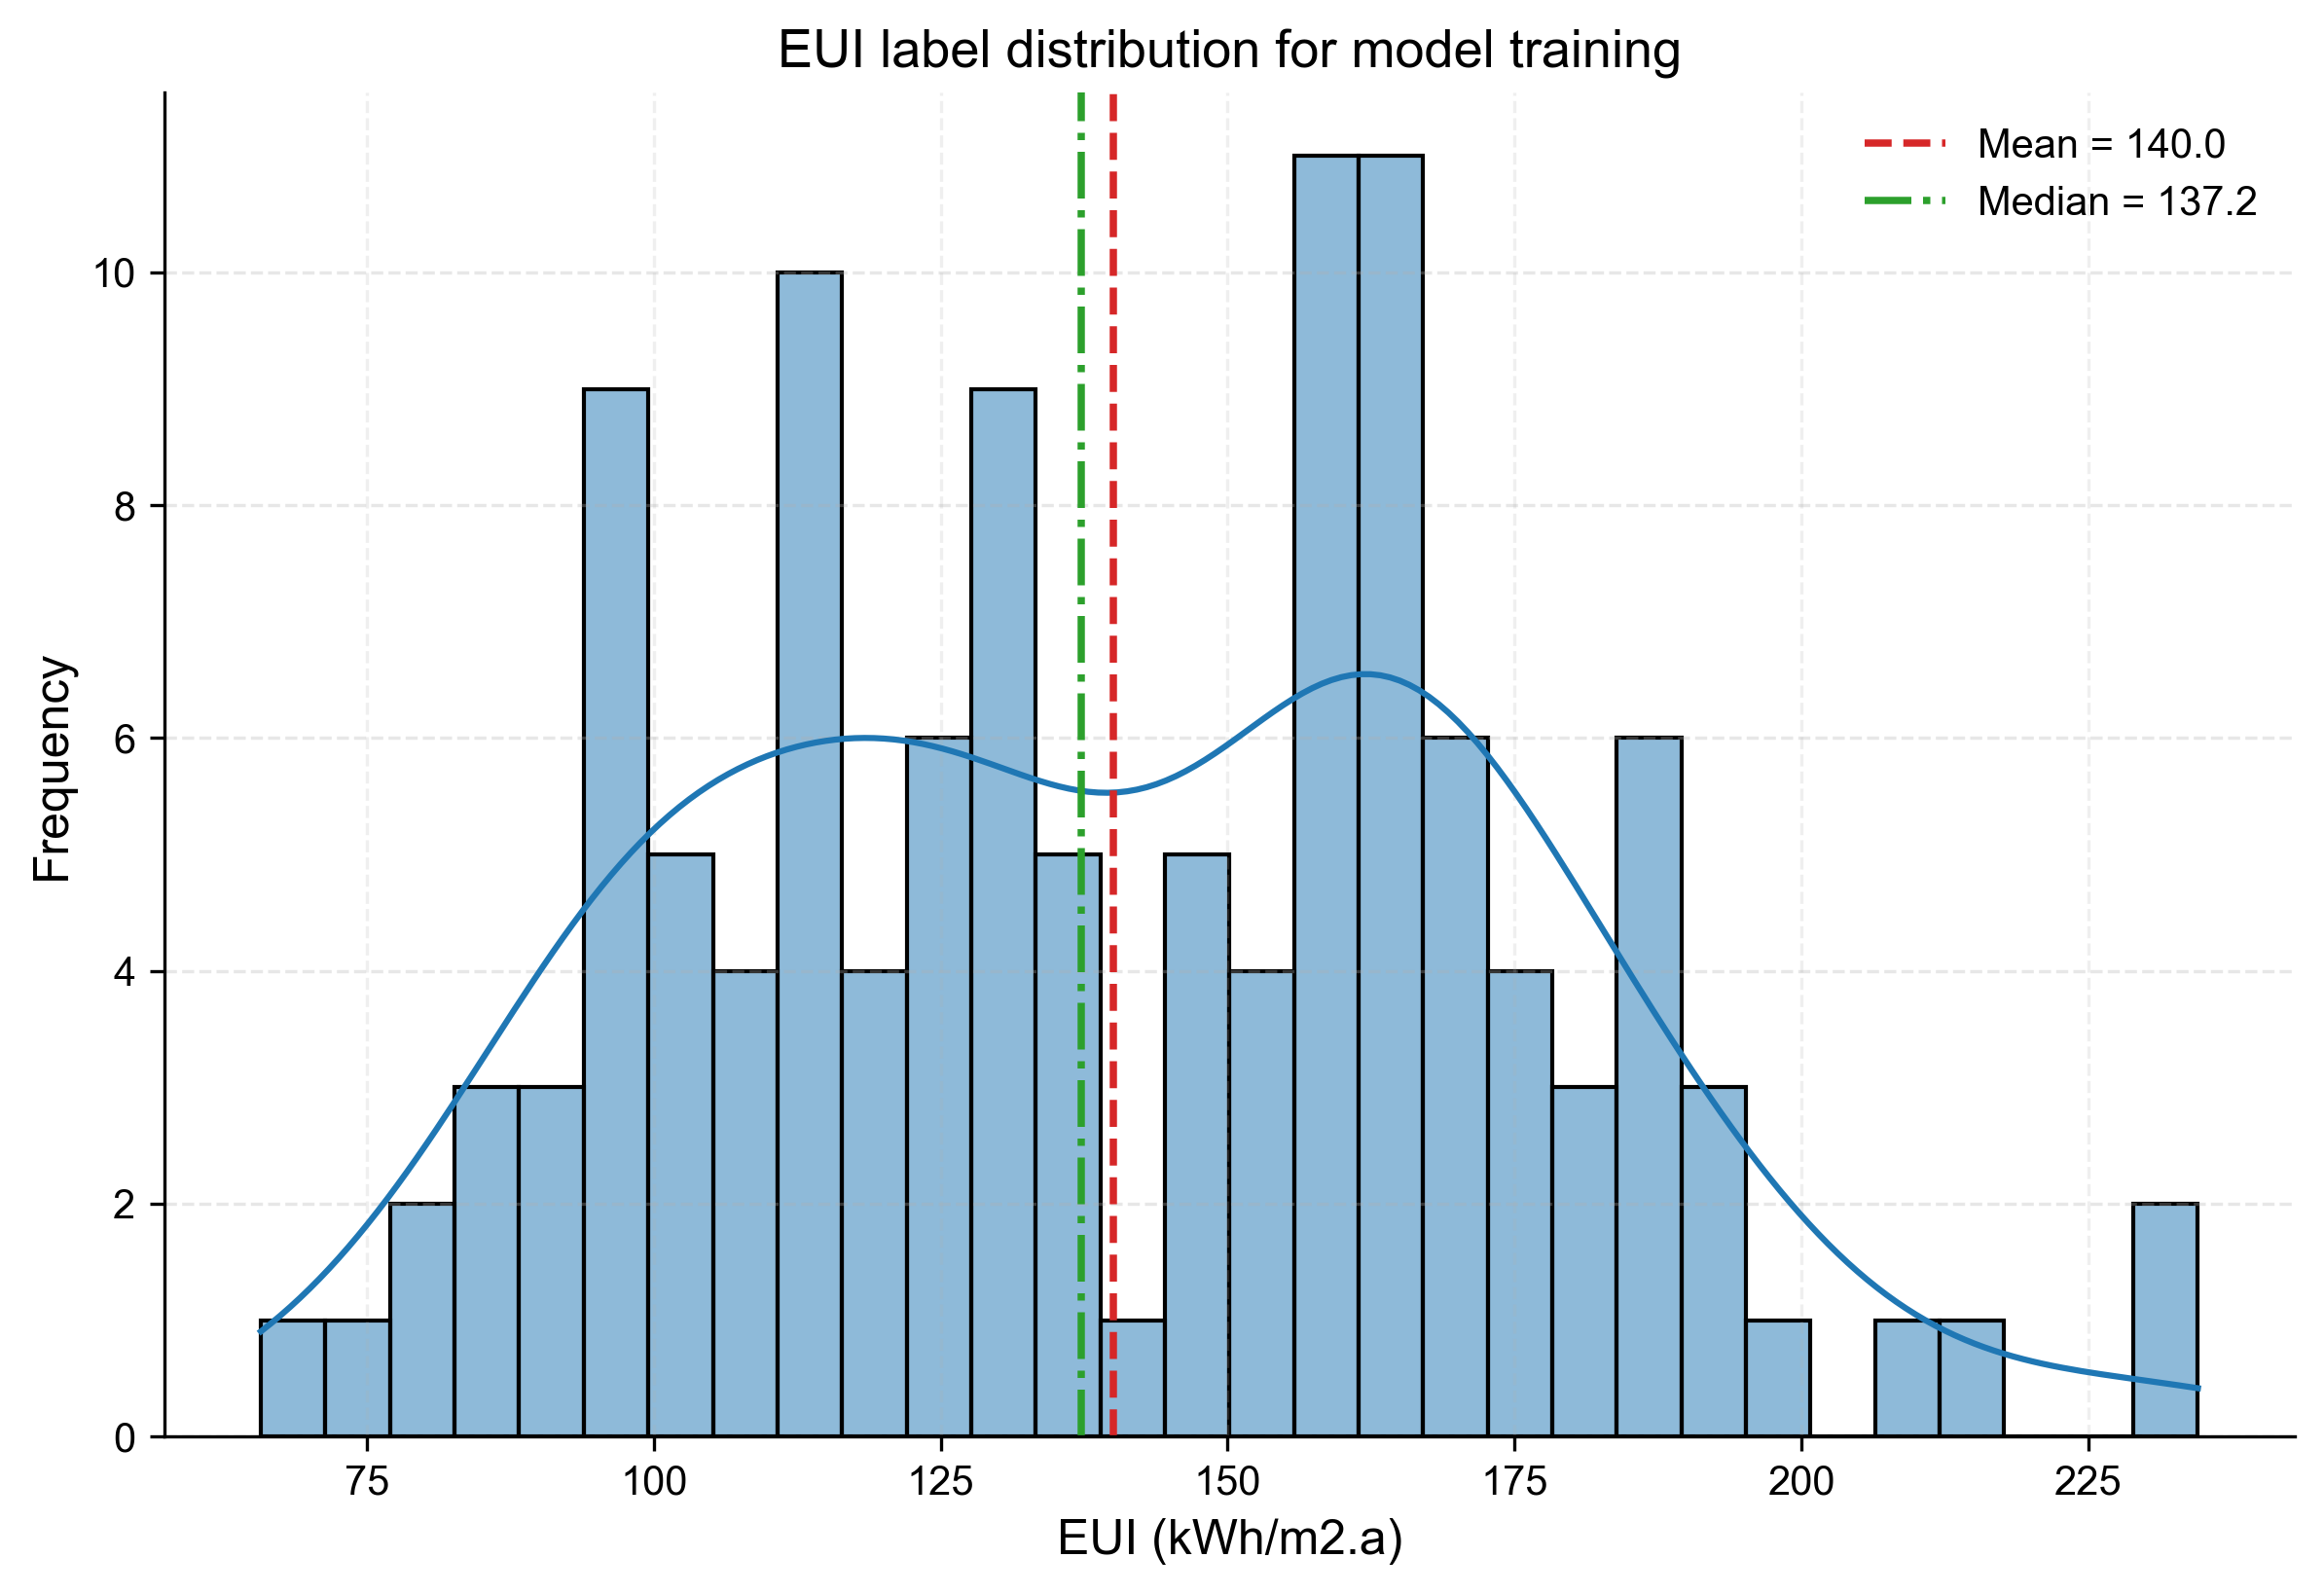

EUI statistics for model training samples:
   metric       value
0    mean  140.023668
1  median  137.240579
2     std   35.459170

CSV saved to: outputs_step3/figures/reconstructed_eui_summary_statistics.csv


In [4]:
# ---------- EUI-label distribution and summary-statistics export ----------
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Extract the EUI label from the training dataset.
eui_data = df[TARGET].dropna()

# Calculate summary statistics.
mean_val = eui_data.mean()
median_val = eui_data.median()
std_val = eui_data.std()

# Plot the distribution.
plt.figure(figsize=(8, 5.5), dpi=300)

sns.histplot(
    eui_data,
    bins=30,
    kde=True,
    stat="count"   # Use frequency/count on the y-axis instead of density.
)

plt.axvline(
    mean_val,
    color="#D62728",
    linestyle="--",
    linewidth=1.8,
    label=f"Mean = {mean_val:.1f}"
)

plt.axvline(
    median_val,
    color="#2CA02C",
    linestyle="-.",
    linewidth=1.8,
    label=f"Median = {median_val:.1f}"
)

plt.xlabel("EUI (kWh/m2.a)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)   # Label the y-axis as Frequency.
plt.title("EUI label distribution for model training", fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(frameon=False, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

# Save the figure.
plt.savefig(FIG_DIR / "Fig_EUI_distribution_for_training_samples.png", dpi=300, bbox_inches="tight")
plt.show()

# Build the summary-statistics table.
summary_df = pd.DataFrame({
    "metric": ["mean", "median", "std"],
    "value": [mean_val, median_val, std_val]
})

# Export the CSV file.
summary_df.to_csv(FIG_DIR / "reconstructed_eui_summary_statistics.csv", index=False, encoding="utf-8-sig")

# Display the result.
print("EUI statistics for model training samples:")
print(summary_df)
print("\nCSV saved to: outputs_step3/figures/reconstructed_eui_summary_statistics.csv")

<!-- CODEx Chinese cell explanation: start -->
### Cell 05 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 05 — Computational step 05

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [5]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import ExtraTreesRegressor

prep_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

prep_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

alphas = np.logspace(-4, 4, 40)

# ---------- 1) Models that do not require an external hyperparameter search ----------
models = {
    "Linear": Pipeline([
        ("prep", prep_linear),
        ("model", LinearRegression())
    ]),

    "RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("model", RidgeCV(alphas=alphas, cv=INNER_CV))
    ]),

    "LassoCV": Pipeline([
        ("prep", prep_linear),
        ("model", LassoCV(
            alphas=alphas,
            cv=INNER_CV,
            max_iter=50000,
            random_state=RANDOM_SEED
        ))
    ]),

    "ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=alphas,
            cv=INNER_CV,
            max_iter=50000,
            random_state=RANDOM_SEED
        ))
    ]),

    "Poly2-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=INNER_CV))
    ]),

    "Poly2-ElasticNetCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-3, 2, 20),
            cv=INNER_CV,
            max_iter=50000,
            random_state=RANDOM_SEED
        ))
    ]),

    "Poly2-Interaction-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-2, 4, 30), cv=INNER_CV))
    ]),

    "Poly3-RidgeCV": Pipeline([
        ("prep", prep_linear),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("poly_scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-1, 5, 30), cv=INNER_CV))
    ]),
}

# ---------- 2) Models tuned with automatic search ----------
searchers = {
    "KNN": GridSearchCV(
        Pipeline([
            ("prep", prep_linear),
            ("model", KNeighborsRegressor())
        ]),
        param_grid={
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        },
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        n_jobs=1
    ),

    "SVR-RBF": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_linear),
            ("model", SVR(kernel="rbf"))
        ]),
        param_distributions={
            "model__C": np.logspace(-1, 2, 20),
            "model__epsilon": np.linspace(0.005, 0.2, 20),
            "model__gamma": ["scale", "auto"]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    ),

    "RandomForest": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=1))
        ]),
        param_distributions={
            "model__n_estimators": [300, 500, 800, 1200],
            "model__max_depth": [None, 6, 8, 12, 16],
            "model__min_samples_split": [2, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    ),

    "ExtraTrees": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", ExtraTreesRegressor(random_state=RANDOM_SEED, n_jobs=1))
        ]),
        param_distributions={
            "model__n_estimators": [300, 500, 800, 1200],
            "model__max_depth": [None, 6, 8, 12, 16],
            "model__min_samples_split": [2, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    ),

    "GB": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", GradientBoostingRegressor(random_state=RANDOM_SEED))
        ]),
        param_distributions={
            "model__n_estimators": [100, 200, 300, 500],
            "model__learning_rate": np.linspace(0.01, 0.15, 15),
            "model__max_depth": [2, 3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    ),

    "MLP": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_linear),
            ("model", MLPRegressor(
                random_state=RANDOM_SEED,
                max_iter=5000,
                early_stopping=True
            ))
        ]),
        param_distributions={
            "model__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "model__alpha": np.logspace(-5, -1, 10),
            "model__activation": ["relu", "tanh"]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    ),

    "DecisionTree": RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", DecisionTreeRegressor(random_state=RANDOM_SEED))
        ]),
        param_distributions={
            "model__max_depth": [None, 4, 6, 8, 12, 16],
            "model__min_samples_split": [2, 4, 8, 12],
            "model__min_samples_leaf": [1, 2, 4, 8]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    ),
}

# ---------- 3) Merge model sets ----------
all_estimators = {}
all_estimators.update(models)
all_estimators.update(searchers)

# ---------- 4) Add XGBoost / LightGBM if available ----------
if HAS_XGB:
    all_estimators["XGBoost"] = RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                random_state=RANDOM_SEED,
                n_jobs=1
            ))
        ]),
        param_distributions={
            "model__n_estimators": [200, 400, 600, 800],
            "model__max_depth": [3, 4, 5, 6],
            "model__learning_rate": np.linspace(0.02, 0.15, 10),
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    )

if HAS_LGBM:
    all_estimators["LightGBM"] = RandomizedSearchCV(
        Pipeline([
            ("prep", prep_tree),
            ("model", LGBMRegressor(random_state=RANDOM_SEED, verbosity=-1, n_jobs=1))
        ]),
        param_distributions={
            "model__n_estimators": [200, 400, 600, 800],
            "model__learning_rate": np.linspace(0.02, 0.15, 10),
            "model__num_leaves": [15, 31, 63],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        n_iter=SEARCH_N_ITER,
        cv=INNER_CV,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_SEED,
        n_jobs=1
    )

search_spaces = {name: getattr(searcher, 'param_distributions', getattr(searcher, 'param_grid', None)) for name, searcher in searchers.items()}
if HAS_XGB:
    search_spaces['XGBoost'] = all_estimators['XGBoost'].param_distributions
if HAS_LGBM:
    search_spaces['LightGBM'] = all_estimators['LightGBM'].param_distributions

print("Total models:", len(all_estimators))
print(list(all_estimators.keys()))

Total models: 17
['Linear', 'RidgeCV', 'LassoCV', 'ElasticNetCV', 'Poly2-RidgeCV', 'Poly2-ElasticNetCV', 'Poly2-Interaction-RidgeCV', 'Poly3-RidgeCV', 'KNN', 'SVR-RBF', 'RandomForest', 'ExtraTrees', 'GB', 'MLP', 'DecisionTree', 'XGBoost', 'LightGBM']


<!-- CODEx Chinese cell explanation: start -->
### Cell 06 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 06 — Computational step 06

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [6]:
def fit_and_compare_models(X_train, y_train, X_test, y_test, estimators):
    rows = []
    fitted_models = {}
    search_objects = {}
    best_params_by_model = {}
    search_objects = {}
    best_params_by_model = {}
    search_objects = {}
    best_params_by_model = {}
    search_objects = {}
    best_params_by_model = {}

    for name, est in estimators.items():
        est.fit(X_train, y_train)

        if hasattr(est, "best_estimator_"):
            best_model = est.best_estimator_
            best_params = est.best_params_
            cv_score = -est.best_score_
        else:
            best_model = est
            best_params = None
            cv_score = np.nan

        pred_train = best_model.predict(X_train)
        pred_test = best_model.predict(X_test)

        cv_result = cross_validate(
            best_model,
            X_train,
            y_train,
            cv=INNER_CV,
            scoring={
                "r2": "r2",
                "neg_rmse": "neg_root_mean_squared_error",
                "neg_mae": "neg_mean_absolute_error"
            },
            n_jobs=1
        )

        cv_r2_scores = cv_result["test_r2"]
        cv_rmse_scores = -cv_result["test_neg_rmse"]
        cv_mae_scores = -cv_result["test_neg_mae"]
        
        rows.append({
            "model": name,
            "train_r2": r2_score(y_train, pred_train),
            "test_r2": r2_score(y_test, pred_test),
            "test_rmse": np.sqrt(mean_squared_error(y_test, pred_test)),
            "test_mae": mean_absolute_error(y_test, pred_test),
            "test_mape": mean_absolute_percentage_error(y_test, pred_test),

            "cv_best_rmse": cv_score,
            "cv_r2_mean": np.mean(cv_r2_scores),
            "cv_r2_std": np.std(cv_r2_scores, ddof=1),
            "cv_r2_variance": np.var(cv_r2_scores, ddof=1),
            "cv_rmse_mean": np.mean(cv_rmse_scores),
            "cv_rmse_std": np.std(cv_rmse_scores, ddof=1),
            "cv_mae_mean": np.mean(cv_mae_scores),

            "best_params": str(best_params)
        })

        fitted_models[name] = best_model
        search_objects[name] = est
        best_params_by_model[name] = best_params
        search_objects[name] = est
        best_params_by_model[name] = best_params
        search_objects[name] = est
        best_params_by_model[name] = best_params
        search_objects[name] = est
        best_params_by_model[name] = best_params
        print(f"done -> {name}")

    result_df = pd.DataFrame(rows)
    result_df["generalization_gap"] = result_df["train_r2"] - result_df["test_r2"]
    result_df = result_df.sort_values(
        ["test_r2", "test_rmse", "generalization_gap"],
        ascending=[False, True, True]
    ).reset_index(drop=True)
    return result_df, fitted_models, search_objects, best_params_by_model


metrics_df, fitted_models, search_objects, best_params_by_model = fit_and_compare_models(
    X_train, y_train, X_test, y_test, all_estimators
)

metrics_df.to_csv(
    OUT_DIR / "model_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

metrics_df

done -> Linear


done -> RidgeCV
done -> LassoCV
done -> ElasticNetCV


done -> Poly2-RidgeCV


done -> Poly2-ElasticNetCV


done -> Poly2-Interaction-RidgeCV


...

done -> GB


done -> MLP
done -> DecisionTree


done -> XGBoost


done -> LightGBM


,model,train_r2,test_r2,test_rmse,test_mae,test_mape,cv_best_rmse,cv_r2_mean,cv_r2_std,cv_r2_variance,cv_rmse_mean,cv_rmse_std,cv_mae_mean,best_params,generalization_gap
0,RidgeCV,0.959629,0.950670,7.519642,5.843921,0.052509,NaN,0.937695,0.015640,0.000245,8.664807,0.895759,6.638750,None,0.008959
1,ElasticNetCV,0.958957,0.949219,7.629401,5.769289,0.051405,NaN,0.936884,0.014526,0.000211,8.734867,0.866136,6.641559,None,0.009738
2,Linear,0.959793,0.948678,7.669946,6.074132,0.054851,NaN,0.938002,0.016071,0.000258,8.637863,0.911197,6.677118,None,0.011114
3,LassoCV,0.959141,0.945353,7.914485,6.020203,0.054019,NaN,0.938286,0.015527,0.000241,8.630809,0.956608,6.608773,None,0.013787
4,Poly2-ElasticNetCV,0.948156,0.779905,15.883508,13.176481,0.107435,NaN,0.655541,0.049957,0.002496,20.533155,2.243036,16.647051,None,0.168251
5,Poly3-RidgeCV,1.000000,0.760018,16.585579,14.349711,0.121118,NaN,0.443716,0.128181,0.016430,25.855825,0.989456,21.205307,None,0.239982
6,XGBoost,0.999893,0.702631,18.462452,15.014064,0.125477,19.704084,0.680064,0.046039,0.002120,19.704084,0.443226,15.180672,"{'model__subsample': 0.9, 'model__n_estimators...",0.297262
7,LightGBM,0.948618,0.697244,18.628913,14.652293,0.125330,20.635725,0.652787,0.025259,0.000638,20.635725,1.815932,15.826481,"{'model__subsample': 1.0, 'model__num_leaves':...",0.251374
8,ExtraTrees,0.911153,0.672270,19.382029,16.000889,0.133987,19.837207,0.676319,0.044865,0.002013,19.837207,0.944095,15.817069,"{'model__n_estimators': 800, 'model__min_sampl...",0.238883
9,GB,1.000000,0.665895,19.569634,15.422838,0.122711,20.201649,0.662414,0.061995,0.003843,20.201649,0.923952,15.834130,"{'model__subsample': 0.7, 'model__n_estimators...",0.334105


<!-- CODEx Chinese cell explanation: start -->
### Cell 07 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 07 — Computational step 07

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [7]:
# ============================================================
# [IMPROVEMENT P1-6] Hyperparameter Tuning Report
# Robustly extract final hyperparameters and search settings.
# ============================================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


def clean_param_dict(params):
    """Remove Pipeline prefixes and convert values to readable strings."""
    cleaned = {}
    if not params:
        return cleaned
    for key, value in params.items():
        clean_key = key.replace("model__", "").replace("prep__", "")
        if isinstance(value, (list, tuple)):
            cleaned[clean_key] = str(value)
        elif hasattr(value, "item"):
            cleaned[clean_key] = value.item()
        else:
            cleaned[clean_key] = value
    return cleaned


def extract_pipeline_model_params(best_model):
    """Extract final estimator parameters from an already fitted Pipeline."""
    params = {}
    estimator = best_model
    if hasattr(best_model, "named_steps"):
        estimator = best_model.named_steps.get("model", best_model)
        if "poly" in best_model.named_steps:
            poly = best_model.named_steps["poly"]
            params["polynomial_degree"] = getattr(poly, "degree", None)
            params["interaction_only"] = getattr(poly, "interaction_only", None)
            params["include_bias"] = getattr(poly, "include_bias", None)
            params["n_polynomial_features"] = getattr(poly, "n_output_features_", None)
    if hasattr(estimator, "alpha_"):
        params["alpha"] = float(estimator.alpha_)
    if hasattr(estimator, "l1_ratio_"):
        params["l1_ratio"] = float(estimator.l1_ratio_)
    for attr in [
        "n_neighbors", "weights", "p", "C", "epsilon", "gamma", "n_estimators",
        "max_depth", "min_samples_split", "min_samples_leaf", "max_features",
        "learning_rate", "subsample", "colsample_bytree", "num_leaves",
        "hidden_layer_sizes", "activation"
    ]:
        if hasattr(estimator, attr):
            params[attr] = getattr(estimator, attr)
    return params


hp_rows = []
for model_name in metrics_df["model"]:
    best_model = fitted_models[model_name]
    search_obj = search_objects.get(model_name)
    row = {
        "model": model_name,
        "search_method": "none",
        "cv_folds": INNER_CV,
        "scoring": "not_applicable",
    }

    if isinstance(search_obj, GridSearchCV):
        row["search_method"] = "GridSearchCV"
        row["scoring"] = search_obj.scoring
        row.update(clean_param_dict(search_obj.best_params_))
        row["best_cv_rmse"] = -float(search_obj.best_score_)
    elif isinstance(search_obj, RandomizedSearchCV):
        row["search_method"] = "RandomizedSearchCV"
        row["n_iter"] = search_obj.n_iter
        row["scoring"] = search_obj.scoring
        row.update(clean_param_dict(search_obj.best_params_))
        row["best_cv_rmse"] = -float(search_obj.best_score_)
    else:
        row["search_method"] = "embedded_cv_or_fixed"
        row.update(extract_pipeline_model_params(best_model))

    hp_rows.append(row)

hp_df = pd.DataFrame(hp_rows)
hp_df.to_csv(OUT_DIR / "model_hyperparameters.csv", index=False, encoding="utf-8-sig")

print("=" * 70)
print("MODEL HYPERPARAMETER REPORT")
print("=" * 70)
display(hp_df)

print("\n" + "=" * 70)
print("TOP 5 MODELS - DETAILED HYPERPARAMETERS")
print("=" * 70)
top5_names = metrics_df.head(5)["model"].tolist()
for name in top5_names:
    print(f"\n--- {name} ---")
    print(hp_df.loc[hp_df["model"] == name].dropna(axis=1).to_string(index=False))
    if name in search_spaces:
        print(f"Search space: {search_spaces[name]}")


MODEL HYPERPARAMETER REPORT


,model,search_method,cv_folds,scoring,alpha,l1_ratio,polynomial_degree,interaction_only,include_bias,n_polynomial_features,...,min_samples_leaf,max_features,hidden_layer_sizes,activation,n_neighbors,p,weights,gamma,epsilon,C
0,RidgeCV,embedded_cv_or_fixed,3,not_applicable,0.492388,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ElasticNetCV,embedded_cv_or_fixed,3,not_applicable,0.074438,0.9,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Linear,embedded_cv_or_fixed,3,not_applicable,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LassoCV,embedded_cv_or_fixed,3,not_applicable,0.119378,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Poly2-ElasticNetCV,embedded_cv_or_fixed,3,not_applicable,0.784760,0.9,2.0,False,False,189.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Poly3-RidgeCV,embedded_cv_or_fixed,3,not_applicable,0.100000,NaN,3.0,False,False,1329.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,XGBoost,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,LightGBM,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ExtraTrees,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,GB,RandomizedSearchCV,3,neg_root_mean_squared_error,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TOP 5 MODELS - DETAILED HYPERPARAMETERS

--- RidgeCV ---
  model        search_method  cv_folds        scoring    alpha
RidgeCV embedded_cv_or_fixed         3 not_applicable 0.492388

--- ElasticNetCV ---
       model        search_method  cv_folds        scoring    alpha  l1_ratio
ElasticNetCV embedded_cv_or_fixed         3 not_applicable 0.074438       0.9

--- Linear ---
 model        search_method  cv_folds        scoring
Linear embedded_cv_or_fixed         3 not_applicable

--- LassoCV ---
  model        search_method  cv_folds        scoring    alpha
LassoCV embedded_cv_or_fixed         3 not_applicable 0.119378

--- Poly2-ElasticNetCV ---
             model        search_method  cv_folds        scoring   alpha  l1_ratio  polynomial_degree interaction_only include_bias  n_polynomial_features
Poly2-ElasticNetCV embedded_cv_or_fixed         3 not_applicable 0.78476       0.9                2.0            False        False                  189.0


<!-- CODEx Chinese cell explanation: start -->
### Cell 08 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 08 — Computational step 08

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [8]:
# ============================================================
# [IMPROVEMENT P1-8] Impact of Fixing Non-Core Variables
#
# Compare model performance when using:
# (a) 18 key variables only (current approach)
# (b) All 39 variables
# to assess whether fixing non-core variables inflates performance.
# ============================================================

# Build the full 39-variable feature set
# (re-load from simulation dataset with all features)
df_full = pd.read_csv(PROJECT_ROOT / 'data' / 'step1_simulation_dataset.csv')

# Apply the same preprocessing: orientation encoding + window type dummies
df_full['orientation_sin'] = np.sin(np.deg2rad(df_full['orientation_deg']))
df_full['orientation_cos'] = np.cos(np.deg2rad(df_full['orientation_deg']))
df_full = pd.get_dummies(df_full, columns=['window_type_id'], prefix='window_type', drop_first=True)

# Select numeric features that were in the original analysis_features
all_39_features = [c for c in analysis_features if c in df_full.columns]
X_full = df_full[all_39_features].copy()
y_full = df_full['eui_kwh_m2'].copy()

# Handle missing/infinite values
X_full = X_full.replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(X_full.median())

# Split same way
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED
)

# Train top 3 models on FULL 39-variable set
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, ElasticNetCV

# Poly3-RidgeCV with 39 vars
pipe_poly3_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler2', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-1, 5, 30), cv=10))
])
pipe_poly3_full.fit(Xf_train, yf_train)
poly3_full_r2 = pipe_poly3_full.score(Xf_test, yf_test)

# XGBoost with 39 vars
if HAS_XGB:
    pipe_xgb_full = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('xgb', XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                         subsample=0.8, random_state=42, n_jobs=1))
    ])
    pipe_xgb_full.fit(Xf_train, yf_train)
    xgb_full_r2 = pipe_xgb_full.score(Xf_test, yf_test)
else:
    xgb_full_r2 = np.nan

# Compare
print("=" * 60)
print("NON-CORE VARIABLE FIXATION ANALYSIS")
print("=" * 60)
print(f"{'Model':<25} {'18 vars R²':>12} {'39 vars R²':>12} {'Delta':>10}")
print("-" * 60)

# Get 18-var results from earlier
poly3_18_r2 = metrics_df.loc[metrics_df['model']=='Poly3-RidgeCV', 'test_r2'].values[0]
xgb_18_r2 = metrics_df.loc[metrics_df['model']=='XGBoost', 'test_r2'].values[0]

print(f"{'Poly3-RidgeCV':<25} {poly3_18_r2:>12.6f} {poly3_full_r2:>12.6f} {poly3_full_r2-poly3_18_r2:>+10.6f}")
print(f"{'XGBoost':<25} {xgb_18_r2:>12.6f} {xgb_full_r2:>12.6f} {xgb_full_r2-xgb_18_r2:>+10.6f}")
print()
print("Interpretation:")
if poly3_full_r2 > poly3_18_r2:
    print(f"  Poly3-RidgeCV improves by {poly3_full_r2-poly3_18_r2:.6f} with all 39 vars — "
          "suggests excluded variables carry residual predictive information.")
else:
    print(f"  Poly3-RidgeCV does NOT improve with all 39 vars — "
          "suggests the 18 key variables capture essentially all EUI variation.")
print("  NOTE: Even if 39-variable performance is marginally higher, the 18-variable set")
print("  is preferred for model simplicity, training efficiency, and practical usability")
print("  in early-stage design when many non-core parameters are not yet determined.")

# Save comparison
noncore_comparison = pd.DataFrame({
    'model': ['Poly3-RidgeCV', 'XGBoost'],
    'r2_18vars': [poly3_18_r2, xgb_18_r2],
    'r2_39vars': [poly3_full_r2, xgb_full_r2],
    'delta': [poly3_full_r2-poly3_18_r2, xgb_full_r2-xgb_18_r2]
})
noncore_comparison.to_csv(PROJECT_ROOT / 'outputs_step3' / 'noncore_variable_impact.csv', index=False)


NON-CORE VARIABLE FIXATION ANALYSIS
Model                       18 vars R²   39 vars R²      Delta
------------------------------------------------------------
Poly3-RidgeCV                 0.760018     0.260514  -0.499504
XGBoost                       0.702631     0.710313  +0.007682

Interpretation:
  Poly3-RidgeCV does NOT improve with all 39 vars — suggests the 18 key variables capture essentially all EUI variation.
  NOTE: Even if 39-variable performance is marginally higher, the 18-variable set
  is preferred for model simplicity, training efficiency, and practical usability
  in early-stage design when many non-core parameters are not yet determined.


### Model hyperparameters and non-core-variable handling

This notebook records the search strategy, selected hyperparameters, and model-evaluation metrics for all candidate regressors. Pipeline objects are used so that imputation and scaling are fitted within the training data or cross-validation folds rather than on the full dataset, reducing information-leakage risk.

The non-core-variable analysis compares the 18-variable feature set against the wider feature set to test whether fixing non-core variables artificially inflates model performance. This result should be reported as evidence for feature-set parsimony, not as proof of real-building predictive accuracy.

<!-- CODEx Chinese cell explanation: start -->
### Cell 09 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 09 — Computational step 09

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

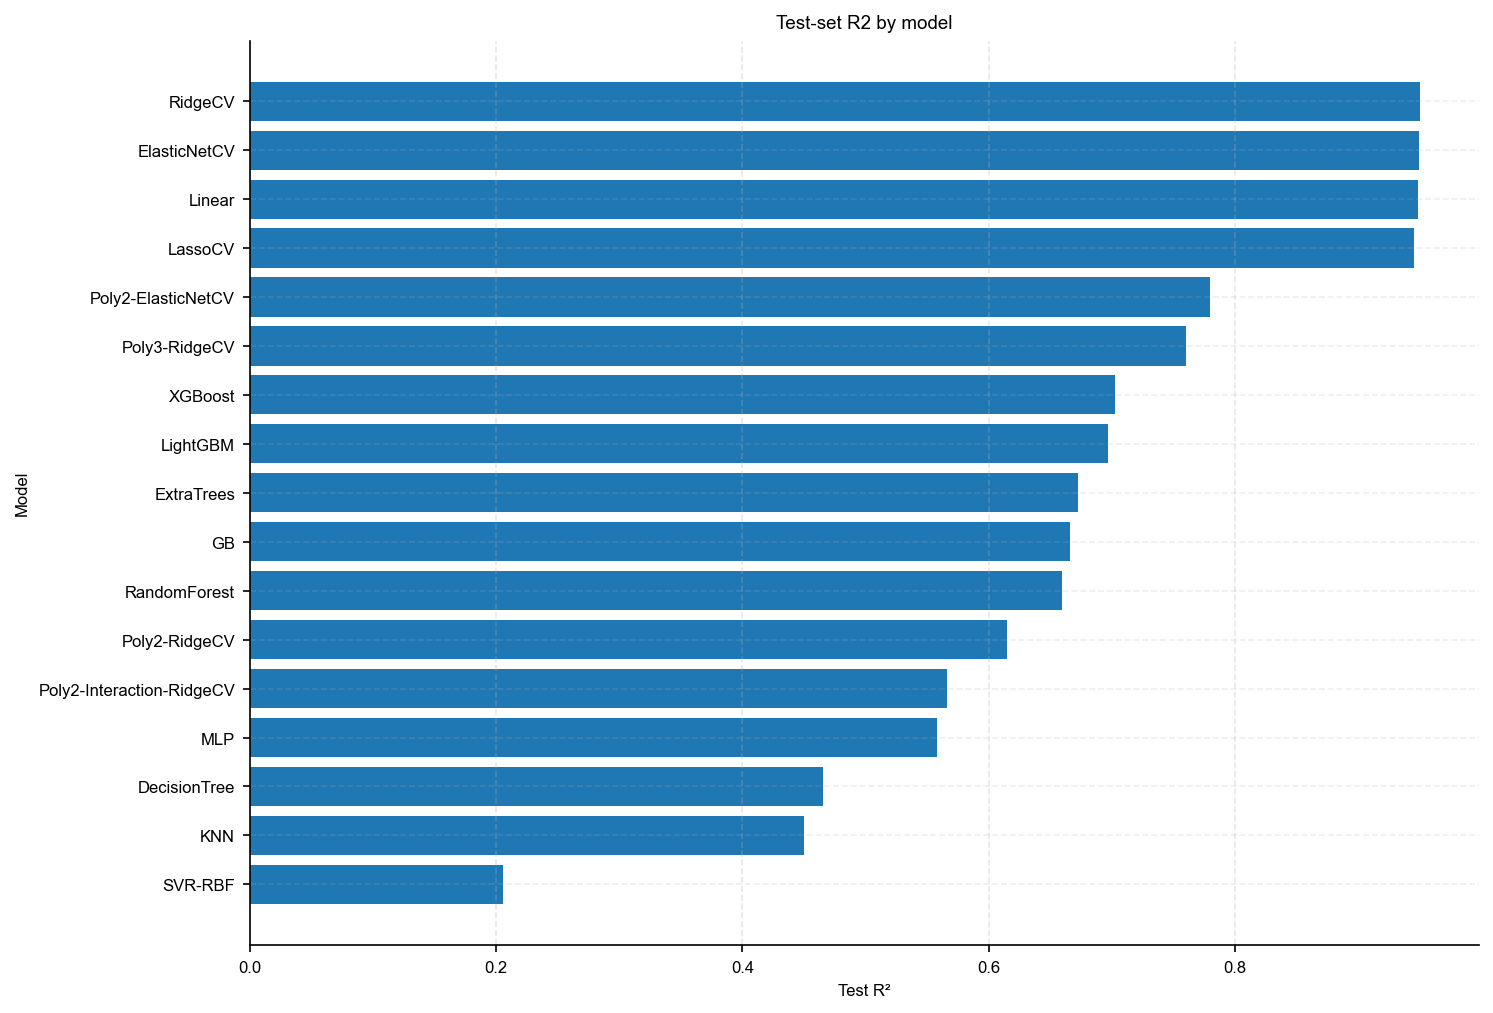

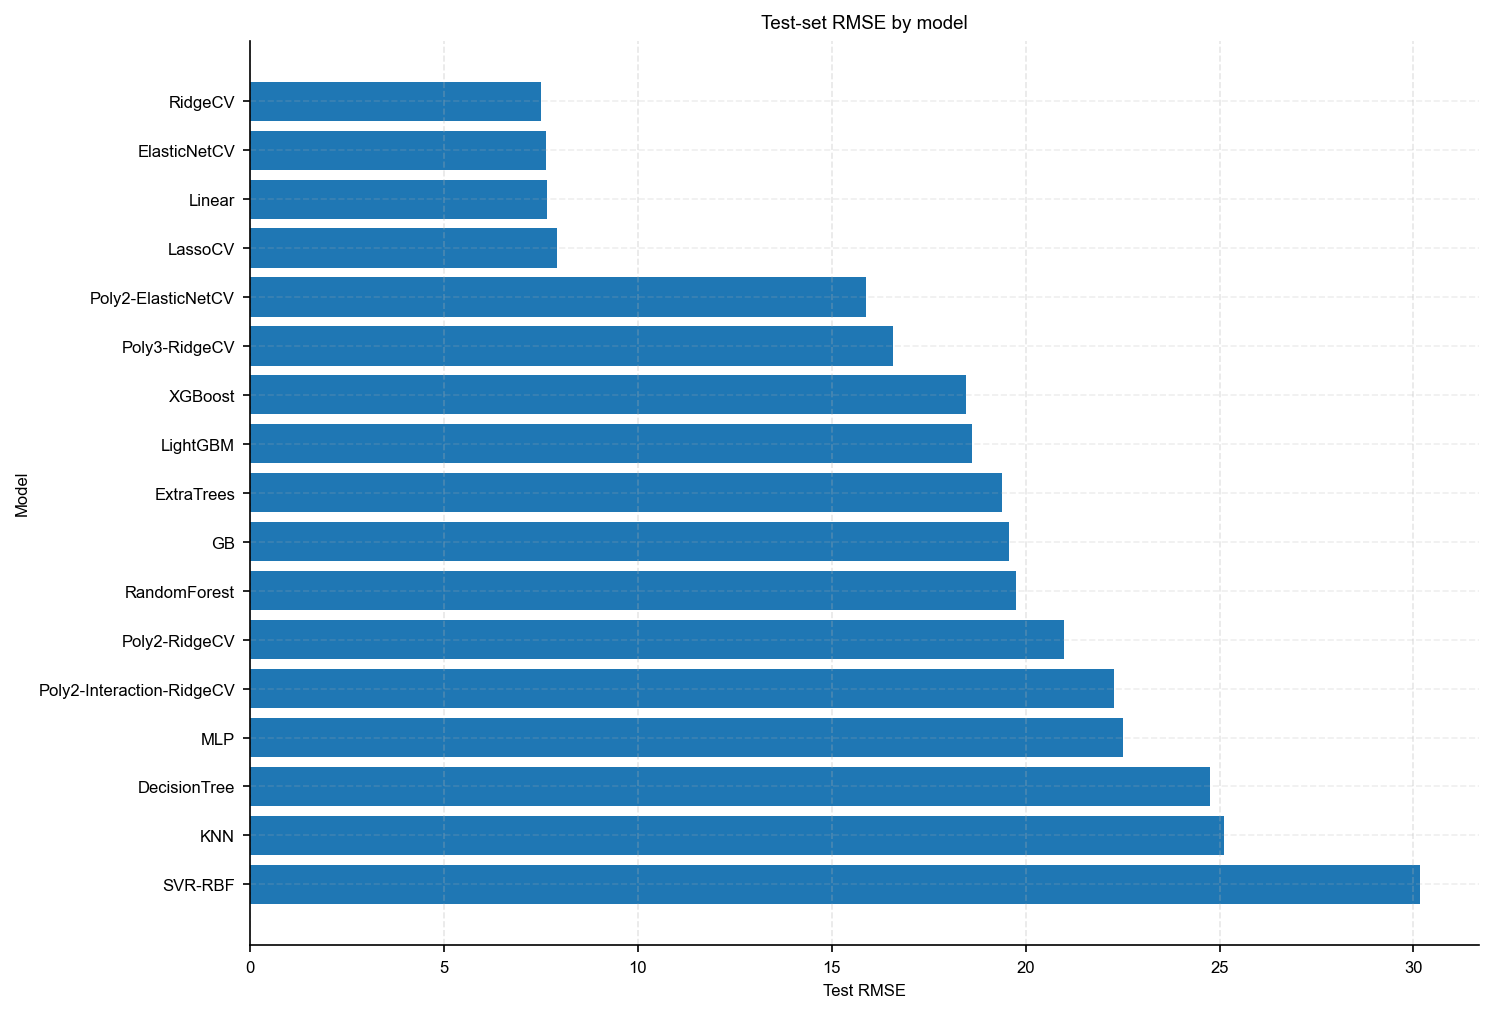

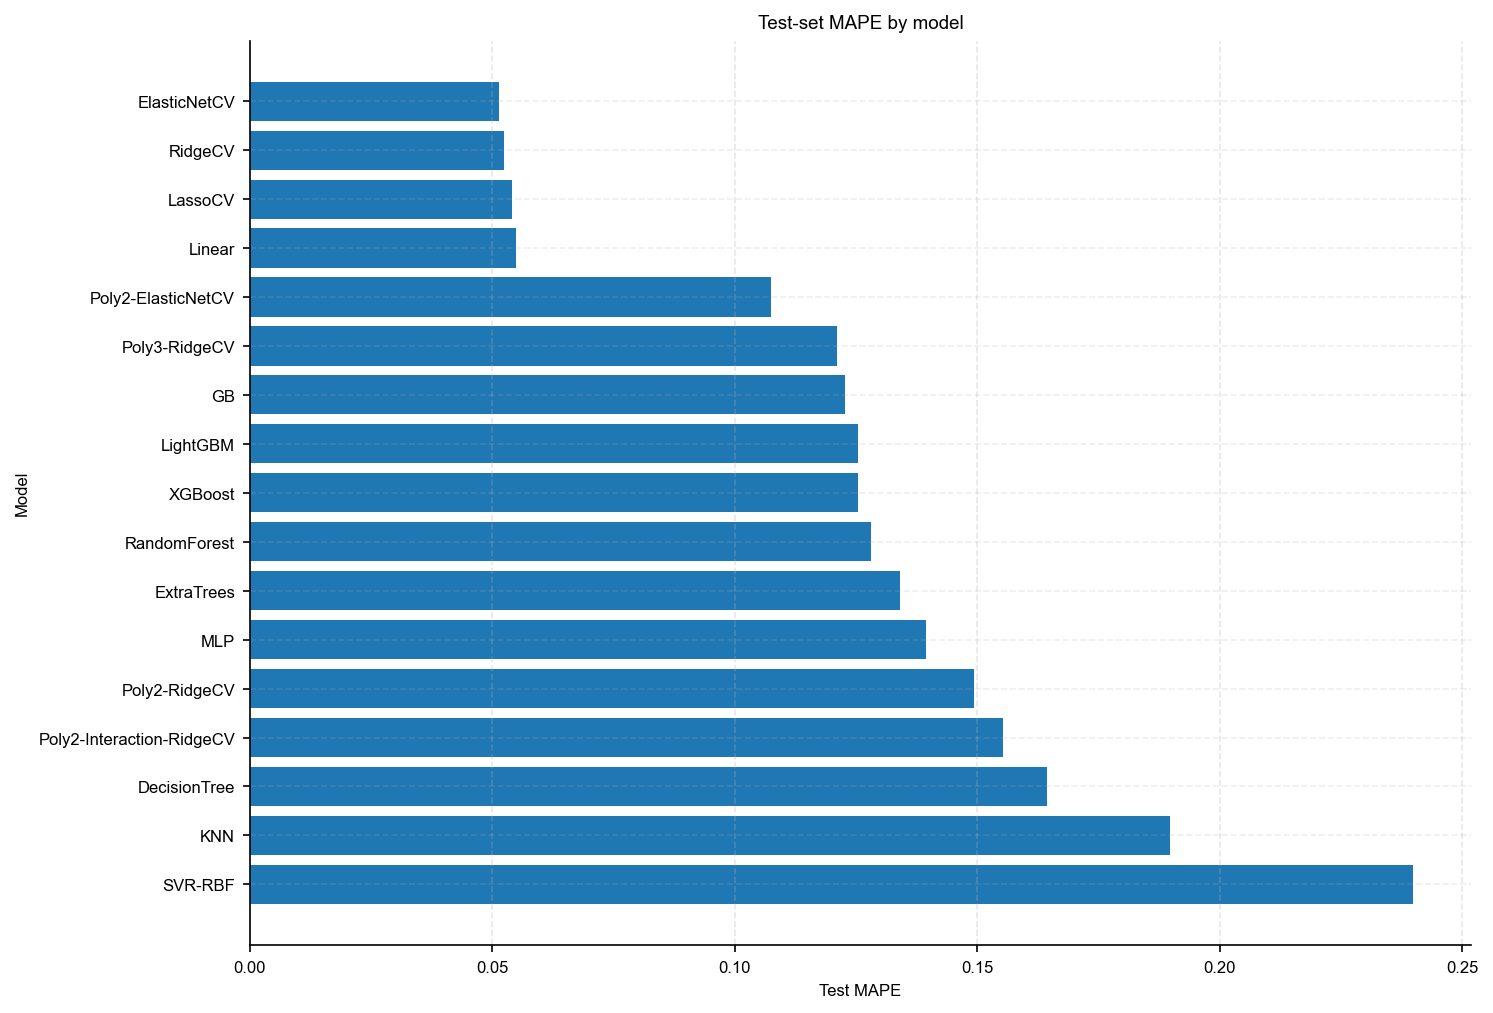

In [9]:
# ----------- 3) Add horizontal-bar visualizations without MAE -----------
plot_df = metrics_df.copy()

for col, title, fname, xlabel in [
    ("test_r2", "Test-set R2 by model", "model_test_r2.png", "Test R²"),
    ("test_rmse", "Test-set RMSE by model", "model_test_rmse.png", "Test RMSE"),
    ("test_mape", "Test-set MAPE by model", "model_test_mape.png", "Test MAPE"),
]:
    fig, ax = plt.subplots(figsize=(10, 6.8))

    # Higher R² is better; lower RMSE and MAPE are better.
    plot_df_sorted = plot_df.sort_values(col, ascending=(col != "test_r2"))

    ax.barh(plot_df_sorted["model"], plot_df_sorted[col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    # Place the best-performing model at the top.
    ax.invert_yaxis()

    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, bbox_inches="tight", dpi=300)
    plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 10 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 10 — Computational step 10

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

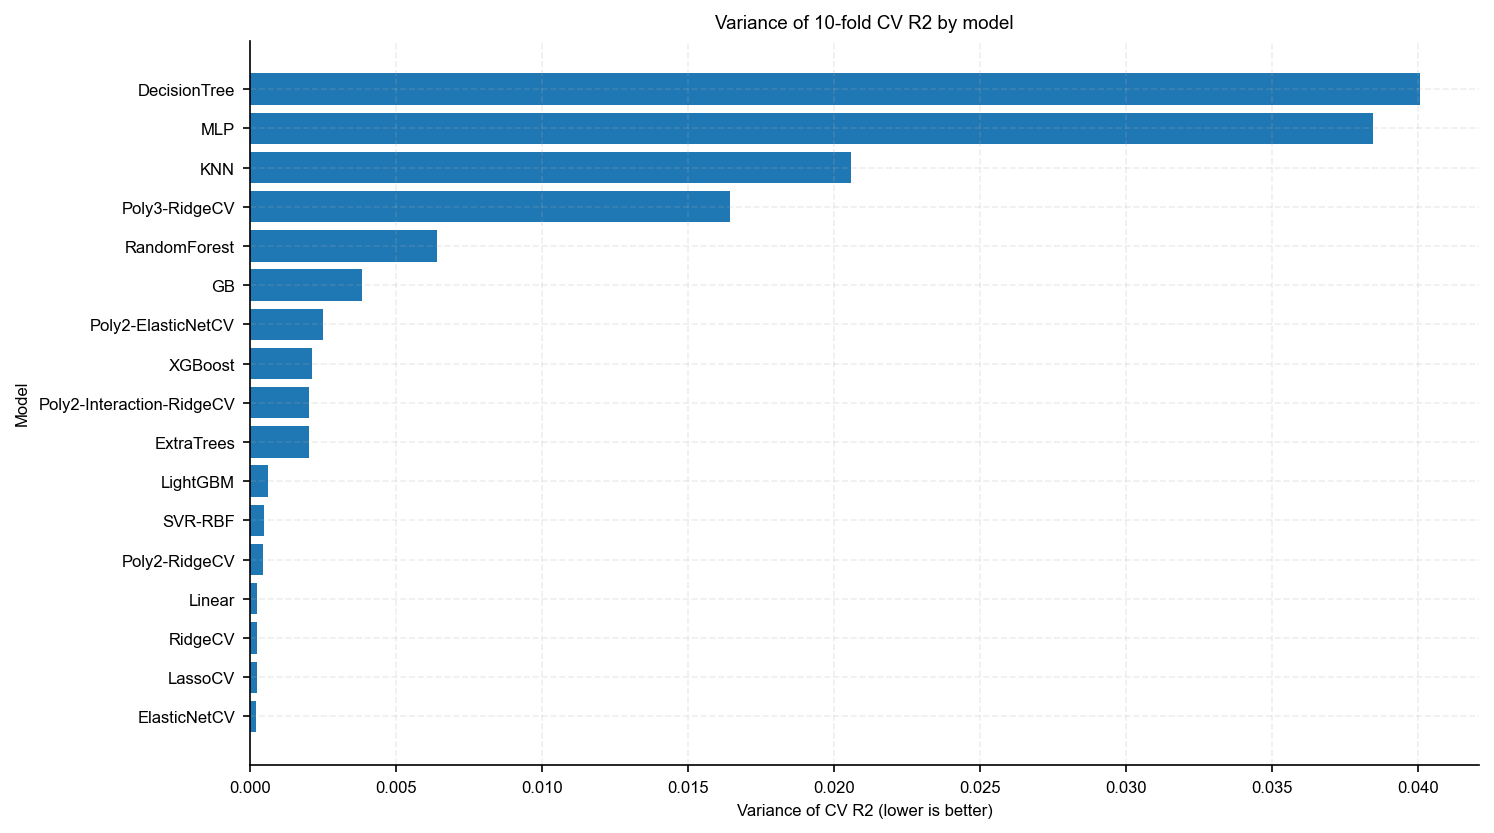

In [10]:
# ---------- 3b) Stability metric visualization: CV R² variance ----------
fig, ax = plt.subplots(figsize=(10, 5.6))
plot_df_sorted = metrics_df.sort_values("cv_r2_variance", ascending=True)
ax.barh(plot_df_sorted["model"], plot_df_sorted["cv_r2_variance"])
ax.set_title("Variance of 10-fold CV R2 by model")
ax.set_xlabel("Variance of CV R2 (lower is better)")
ax.set_ylabel("Model")
fig.tight_layout()
fig.savefig(FIG_DIR / "model_cv_r2_variance.png", bbox_inches="tight")
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 11 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 11 — Computational step 11

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [11]:
best2 = metrics_df.head(2)["model"].tolist()
print("Top 2 models:", best2)

final_models = {}
best_params_rows = []

for name in best2:
    model = fitted_models[name]
    final_models[name] = model
    joblib.dump(model, MODEL_DIR / f"{name}_eui_model.joblib")

    row = metrics_df.loc[metrics_df["model"] == name].iloc[0]
    best_params_rows.append({
        "model": name,
        "best_params": row["best_params"]
    })

pd.DataFrame(best_params_rows).to_csv(
    OUT_DIR / "best_model_params.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.Series(best2, name="best2_models").to_csv(
    OUT_DIR / "best2_models.csv",
    index=False,
    encoding="utf-8-sig"
)

Top 2 models: ['RidgeCV', 'ElasticNetCV']


<!-- CODEx Chinese cell explanation: start -->
### Cell 12 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 12 — Computational step 12

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

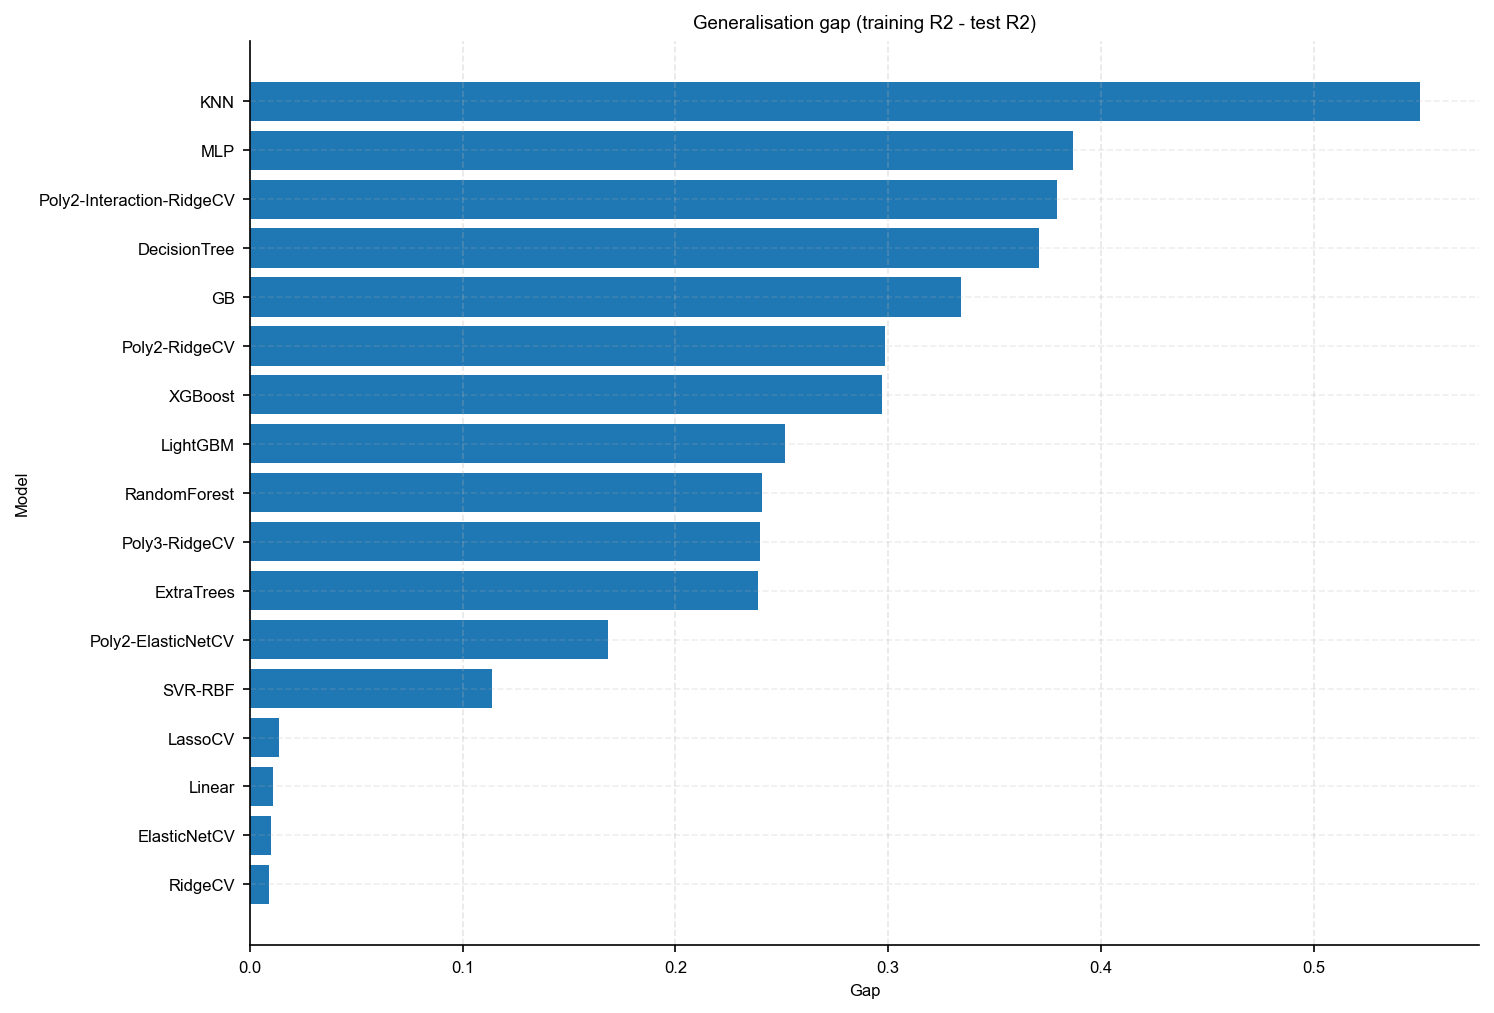

In [12]:
# ----------- 4) Generalization-gap visualization -----------
gap_df = metrics_df.copy()
gap_df["generalization_gap"] = gap_df["train_r2"] - gap_df["test_r2"]

# Sort by the gap in descending order to identify stronger overfitting.
gap_df = gap_df.sort_values("generalization_gap", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6.8))
ax.barh(gap_df["model"], gap_df["generalization_gap"])
ax.set_title("Generalisation gap (training R2 - test R2)")
ax.set_xlabel("Gap")
ax.set_ylabel("Model")
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Place the largest gap at the top.
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIG_DIR / "generalization_gap.png", bbox_inches="tight", dpi=300)
plt.show()

<!-- CODEx Chinese cell explanation: start -->
### Cell 13 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 13 — Computational step 13

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

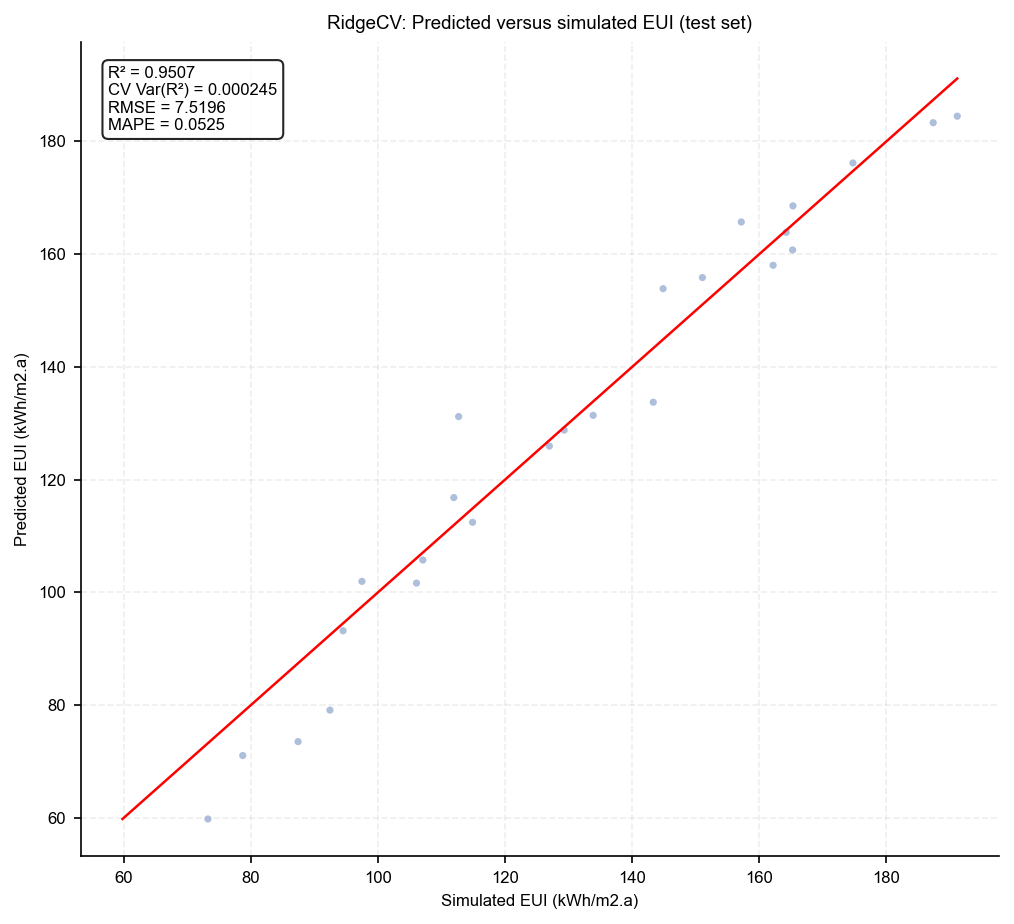

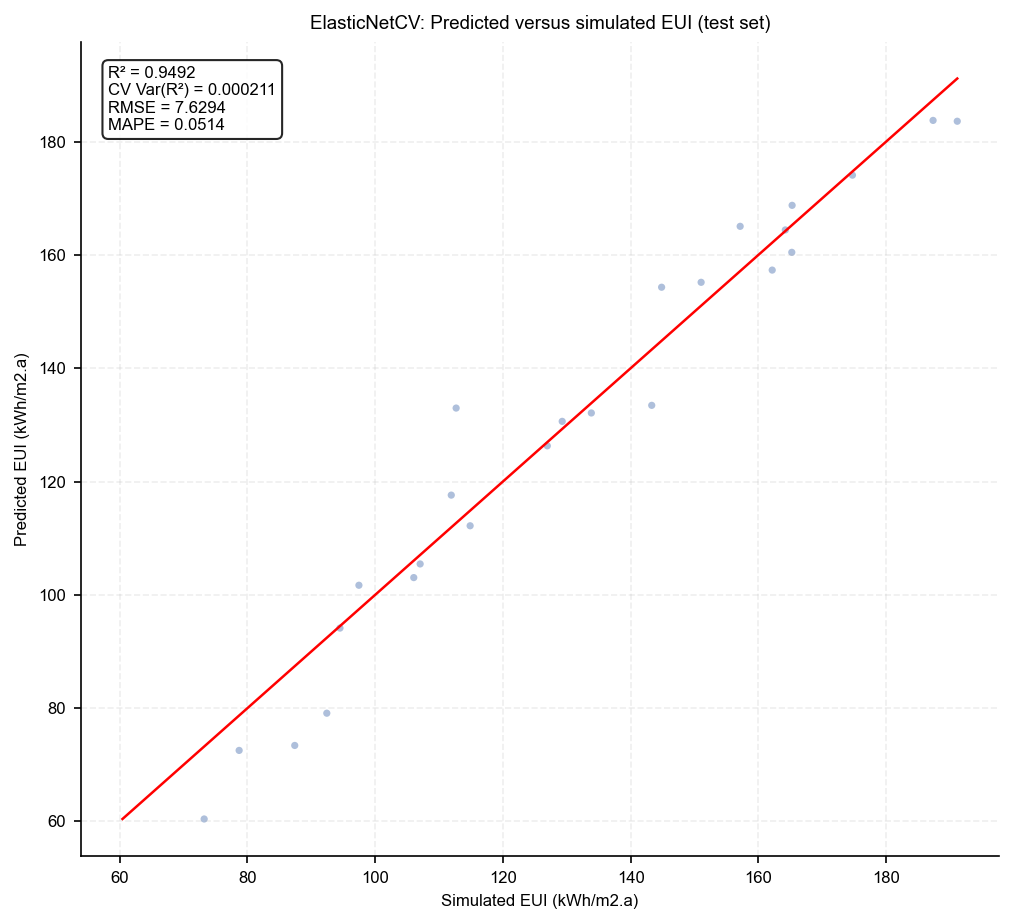

In [13]:
for name in best2:
    model = fitted_models[name]
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)

    fig, ax = plt.subplots(figsize=(6.8, 6.2))
    ax.scatter(
        y_test, pred,
        s=12,
        alpha=0.45,
        color="#4C72B0",
        edgecolors="none",
        rasterized=True
    )

    lo = min(y_test.min(), np.min(pred))
    hi = max(y_test.max(), np.max(pred))
    ax.plot([lo, hi], [lo, hi], linewidth=1.2, color='red')

    ax.set_title(f"{name}: Predicted versus simulated EUI (test set)")
    ax.set_xlabel("Simulated EUI (kWh/m2.a)")
    ax.set_ylabel("Predicted EUI (kWh/m2.a)")

    row = metrics_df.loc[metrics_df["model"] == name].iloc[0]
    
    txt = (
        f"R² = {r2:.4f}\n"
        f"CV Var(R²) = {row['cv_r2_variance']:.6f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"MAPE = {mape:.4f}"
    )
    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85)
    )

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}_pred_vs_sim_test.png", bbox_inches="tight")
    plt.show()

    pred_df = pd.DataFrame({
        "y_true": y_test.values,
        "y_pred": pred
    })
    pred_df.to_csv(
        OUT_DIR / f"{name}_test_predictions.csv",
        index=False,
        encoding="utf-8-sig"
    )